# チャレンジ！
歩いている時の筋肉の動きを見てみよう！
![](https://raw.githubusercontent.com/Otakosuke1/signal_preprocess/main/share/歩行周期.png)
(https://tatikawa-treatment.com/walking/ )

# Step0. 必要なパッケージのインポート

In [1]:
# パッケージのインポート
import pandas as pd #テーブルを扱うためのパッケージ
import numpy as np #数値計算のためのパッケージ
import scipy #信号処理のパッケージ
import matplotlib.pyplot as plt #図表作成のパッケージ

# Step1. データの読み込み

In [2]:
#データのロード
emg_path = "https://raw.githubusercontent.com/Otakosuke1/signal_preprocess/refs/heads/main/share/emg.csv"
emg_data = pd.read_csv(emg_path, index_col=0) #pandasのread_csv関数でファイルをデータテーブルにする

In [3]:
emg_data.head()

,time,Voltage.RGAS,Voltage.RVL
0,0.000,-0.091133,0.000763
1,0.001,-0.122032,0.017738
2,0.002,-0.095901,0.014305
3,0.003,-0.049171,-0.000191
4,0.004,-0.011635,0.007782


In [4]:
emg_data.shape

(3370, 3)

In [5]:
force_path = "https://raw.githubusercontent.com/Otakosuke1/signal_preprocess/refs/heads/main/share/force_ref.csv"
force_data = pd.read_csv(force_path, index_col=0)
force_data.shape

(3370, 3)

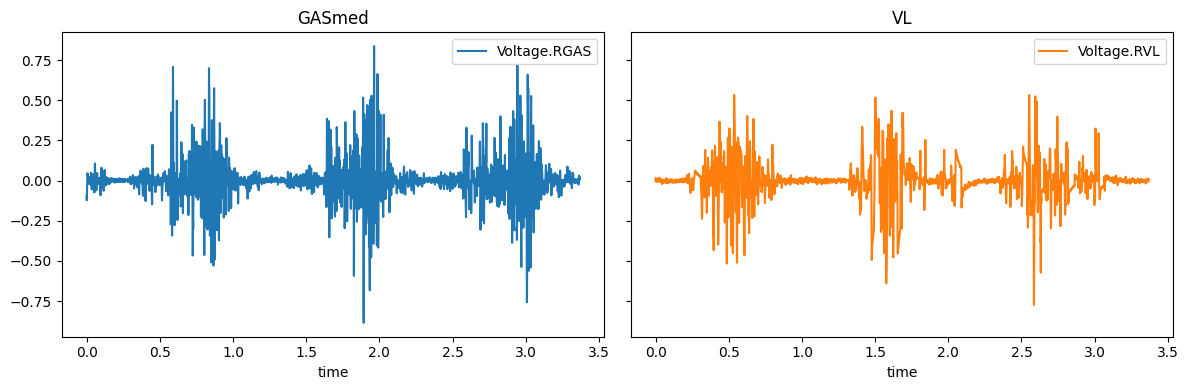

In [6]:
# 確認用プロット
# 1. 1行2列の描画領域（オブジェクト）を作成
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
# 2. 1列目のグラフ (axes[0]) に GAS をプロット
emg_data.plot(x = "time", y = "Voltage.RGAS", ax=axes[0], title="GASmed", color="C0")
# 3. 2列目のグラフ (axes[1]) に VL をプロット
emg_data.plot(x = "time", y ="Voltage.RVL", ax=axes[1], title="VL", color="C1")

# レイアウトの自動調整
plt.tight_layout()
plt.show()

In [7]:
force_data.head()

,time,Force.Fz1,Force.Fz4
0,0.000,0.0,-16.117792
1,0.001,0.0,-16.847254
2,0.002,0.0,-16.372898
3,0.003,0.0,-16.285421
4,0.004,0.0,-16.255274


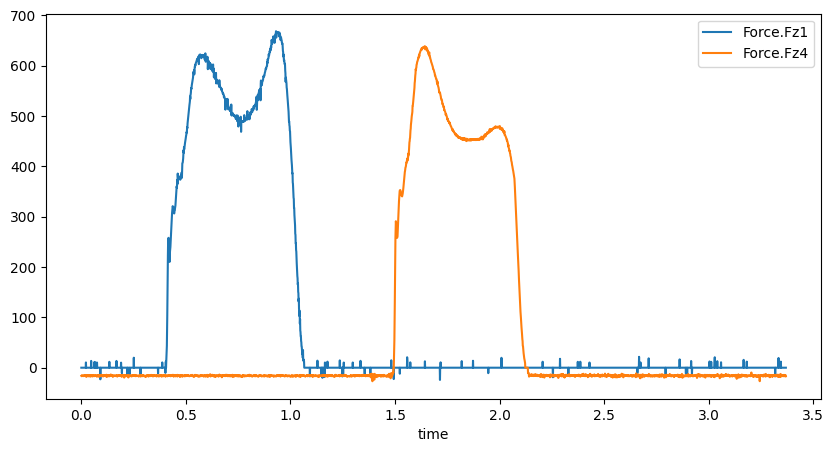

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
force_data.plot(x="time", y=["Force.Fz1", "Force.Fz4"], ax=ax)
plt.show()

# Step2. データの前処理
- フィルタリング (10 ~ 499Hzのバンドパス)
- 整流化(abs)
- 平滑化(6Hz, 4次バターワース)
- エポッキング(force_dataをもとに、20Nを上限。初めて20Nを超えたところから次に20Nを超えたところまで)
- 時間正規化(101タイムポイントに)
- 振幅正規化(最大値を1にする正規化方法)

In [9]:
from scipy import signal

col_list = ['Voltage.RGAS', 'Voltage.RVL']
# サンプリング周波数の定義
fs = 1000
nyq = 0.5 * fs

# 1. フィルタリング 
# 今回はフィルタリングの効果がわかりやすいよう、20Hz ~ 300Hz のバンドパスフィルタを使用する
# 本来は、その信号の特性に応じて、適切なフィルタを選択する必要がある
low = 20 / nyq
high = 300 / nyq
b_bp, a_bp = signal.butter(4, [low, high], btype='band')

emg_filtered = emg_data.copy()
for col in col_list:
    emg_filtered[col] = signal.filtfilt(b_bp, a_bp, emg_data[col])

# 2. 整流化 (絶対値)
emg_rectified = emg_filtered.copy()
for col in col_list:
    emg_rectified[col] = np.abs(emg_filtered[col])

# 3. 平滑化 (6Hz, 4次バターワース ローパス)
b_lp, a_lp = signal.butter(4, 6 / nyq, btype='low')
emg_smoothed = emg_rectified.copy()
for col in col_list:
    emg_smoothed[col] = signal.filtfilt(b_lp, a_lp, emg_rectified[col])

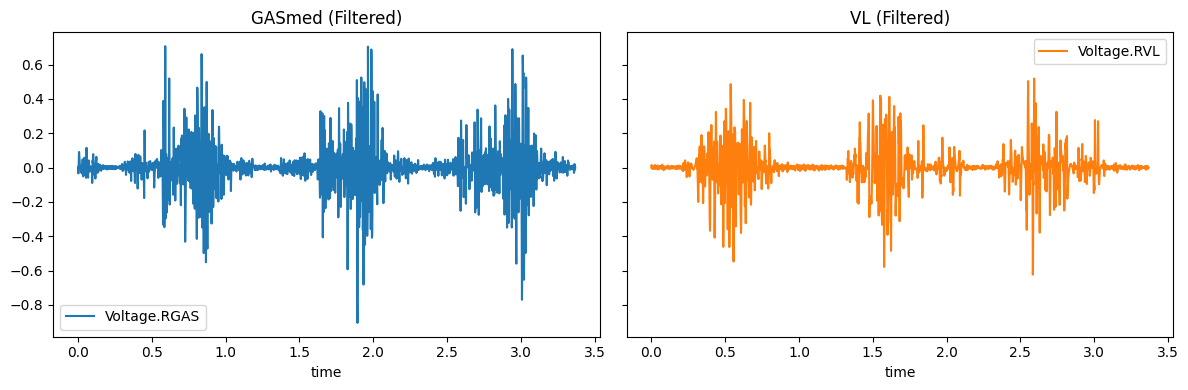

In [10]:
# フィルタリングの結果をプロット
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

emg_filtered.plot(x = "time", y = "Voltage.RGAS", ax=axes[0], title="GASmed (Filtered)", color="C0")
emg_filtered.plot(x = "time", y = "Voltage.RVL", ax=axes[1], title="VL (Filtered)", color="C1")

# レイアウトの自動調整
plt.tight_layout()
plt.show()

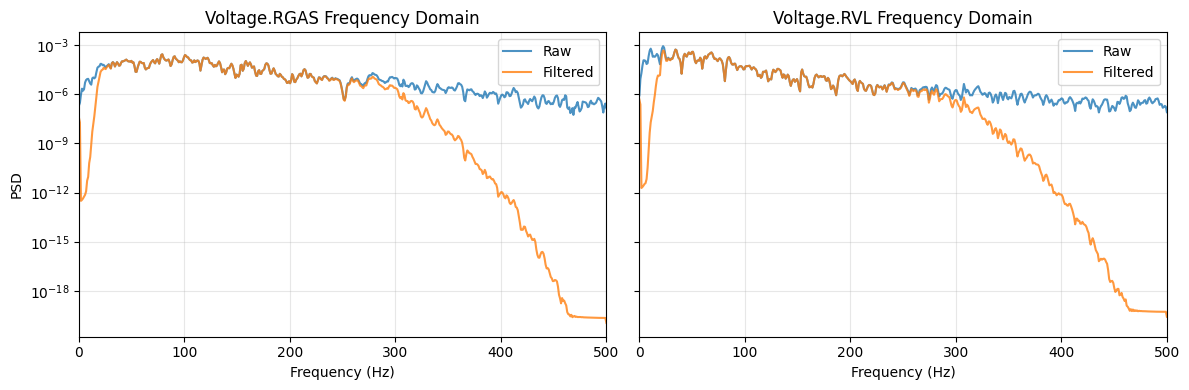

In [ ]:
# フィルタリング前後の周波数領域比較（Welch法）
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

f_raw_gas, p_raw_gas = signal.welch(emg_data['Voltage.RGAS'].values, fs=fs, nperseg=1024)
f_flt_gas, p_flt_gas = signal.welch(emg_filtered['Voltage.RGAS'].values, fs=fs, nperseg=1024)

axes[0].semilogy(f_raw_gas, p_raw_gas, label="Raw", alpha=0.8)
axes[0].semilogy(f_flt_gas, p_flt_gas, label="Filtered", alpha=0.8)
axes[0].set_xlim(0, 500)
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("PSD")
axes[0].set_title("Voltage.RGAS Frequency Domain")
axes[0].grid(alpha=0.3)
axes[0].legend()

f_raw_vl, p_raw_vl = signal.welch(emg_data['Voltage.RVL'].values, fs=fs, nperseg=1024)
f_flt_vl, p_flt_vl = signal.welch(emg_filtered['Voltage.RVL'].values, fs=fs, nperseg=1024)

axes[1].semilogy(f_raw_vl, p_raw_vl, label="Raw", alpha=0.8)
axes[1].semilogy(f_flt_vl, p_flt_vl, label="Filtered", alpha=0.8)
axes[1].set_xlim(0, 500)
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_title("Voltage.RVL Frequency Domain")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

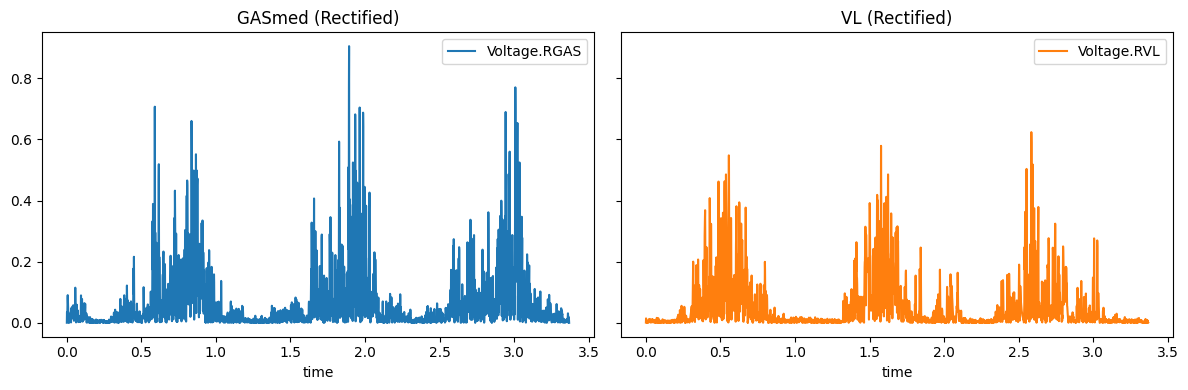

In [12]:
# 整流化の結果をプロット
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

emg_rectified.plot(x = "time", y = "Voltage.RGAS", ax=axes[0], title="GASmed (Rectified)", color="C0")
emg_rectified.plot(x = "time", y = "Voltage.RVL", ax=axes[1], title="VL (Rectified)", color="C1")

# レイアウトの自動調整
plt.tight_layout()
plt.show()

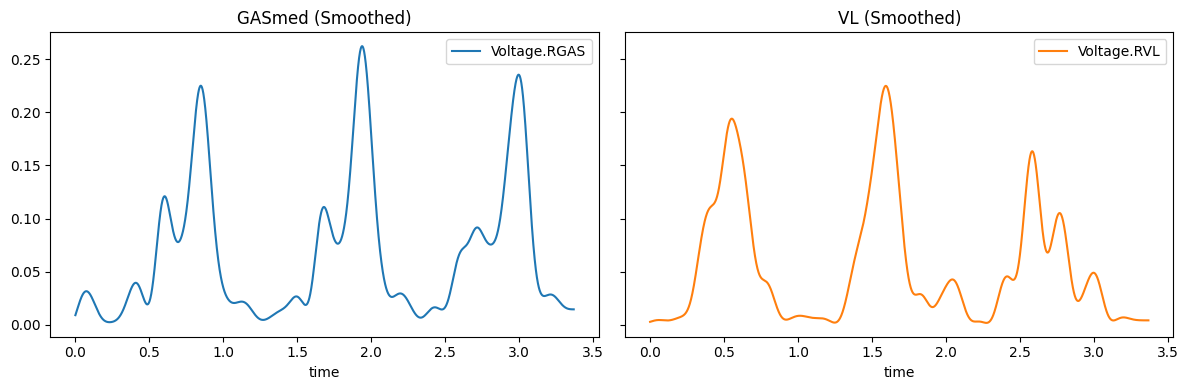

In [13]:
# 平滑化の結果をプロット
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

emg_smoothed.plot(x = "time", y = "Voltage.RGAS", ax=axes[0], title="GASmed (Smoothed)", color="C0")
emg_smoothed.plot(x = "time", y = "Voltage.RVL", ax=axes[1], title="VL (Smoothed)", color="C1")

# レイアウトの自動調整
plt.tight_layout()
plt.show()

In [14]:
# 4. エポッキング
threshold = 20
first_hc_time = (force_data["Force.Fz1"] > 20).idxmax()
second_hc_time = (force_data["Force.Fz4"] > 20).idxmax()

In [15]:
epoch = emg_smoothed.iloc[first_hc_time:second_hc_time, :]

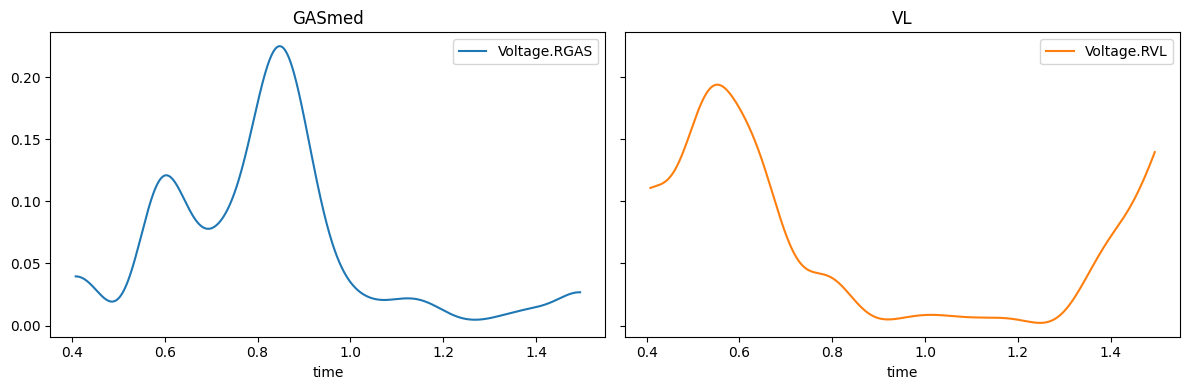

In [16]:
# 1. 1行2列の描画領域（オブジェクト）を作成
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
# 2. 1列目のグラフ (axes[0]) に GAS をプロット
epoch.plot(x = "time", y = "Voltage.RGAS", ax=axes[0], title="GASmed", color="C0")
# 3. 2列目のグラフ (axes[1]) に VL をプロット
epoch.plot(x = "time", y = "Voltage.RVL", ax=axes[1], title="VL", color="C1")

# レイアウトの自動調整
plt.tight_layout()
plt.show()

In [17]:
import numpy as np
from scipy.interpolate import interp1d

# 変更前の行数と、変更後の目標行数
old_rows, new_rows = epoch.shape[0], 101

# リサンプリング用の関数を作成（線形補間）
x_old = np.linspace(0, 1, old_rows)
x_new = np.linspace(0, 1, new_rows)
f = interp1d(x_old, epoch.values, axis=0, kind="linear")

# 101行のデータフレームを再構築
short_data = pd.DataFrame(f(x_new), columns=epoch.columns)

# 歩行周期(%)を横軸として使えるように追加
short_data["gait_cycle"] = np.linspace(0, 100, new_rows)
print(short_data.shape)

(101, 4)


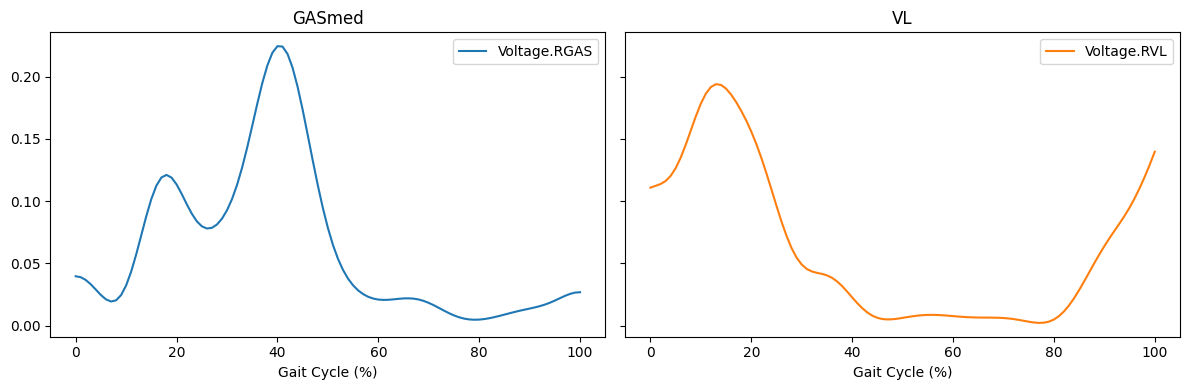

In [18]:
# 1. 1行2列の描画領域（オブジェクト）を作成
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
# 2. 1列目のグラフ (axes[0]) に GAS をプロット
short_data.plot(x="gait_cycle", y="Voltage.RGAS", ax=axes[0], title="GASmed", color="C0")
axes[0].set_xlabel("Gait Cycle (%)")
# 3. 2列目のグラフ (axes[1]) に VL をプロット
short_data.plot(x="gait_cycle", y="Voltage.RVL", ax=axes[1], title="VL", color="C1")
axes[1].set_xlabel("Gait Cycle (%)")

# レイアウトの自動調整
plt.tight_layout()
plt.show()

In [19]:
target_cols = ["Voltage.RGAS", "Voltage.RVL"]

# 振幅正規化（各筋の最大値で正規化）
normalized_df = short_data[["gait_cycle"] + target_cols].copy()
normalized_df[target_cols] = normalized_df[target_cols] / normalized_df[target_cols].max()

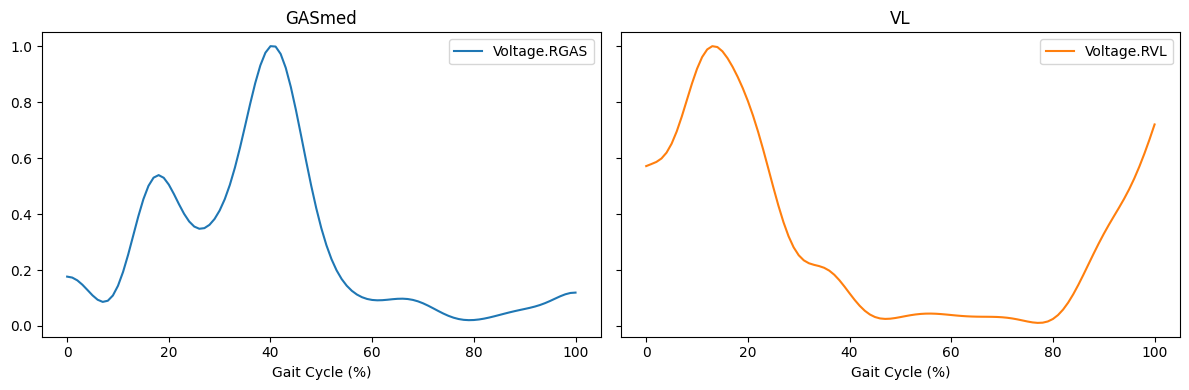

In [20]:
# 1. 1行2列の描画領域（オブジェクト）を作成
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
# 2. 1列目のグラフ (axes[0]) に GAS をプロット
normalized_df.plot(x="gait_cycle", y="Voltage.RGAS", ax=axes[0], title="GASmed", color="C0")
axes[0].set_xlabel("Gait Cycle (%)")
# 3. 2列目のグラフ (axes[1]) に VL をプロット
normalized_df.plot(x="gait_cycle", y="Voltage.RVL", ax=axes[1], title="VL", color="C1")
axes[1].set_xlabel("Gait Cycle (%)")

# レイアウトの自動調整
plt.tight_layout()
plt.show()

# リファレンスと比較
!["腓腹筋"](https://raw.githubusercontent.com/Otakosuke1/signal_preprocess/main/share/Gmed.png)
!["外側広筋"](https://raw.githubusercontent.com/Otakosuke1/signal_preprocess/main/share/VL.png)<br>
https://doi.org/10.1113/jphysiol.2003.057174　
